In [1]:
import pandas as pd
import numpy as np
from google.colab import files
uploaded = files.upload()
train_values = pd.read_csv('train_values.csv')
train_labels = pd.read_csv('train_labels.csv')

Saving train_labels.csv to train_labels.csv
Saving train_values.csv to train_values.csv


In [13]:
df = pd.merge(train_values, train_labels, on='building_id')
print("Train Values Shape:", train_values.shape)
print("Train Labels Shape:", train_labels.shape)
train_labels.head(5)
df = df.drop('building_id', axis=1)

Train Values Shape: (260601, 39)
Train Labels Shape: (260601, 2)


In [14]:
df.isnull().sum()


,0
geo_level_1_id,0
geo_level_2_id,0
geo_level_3_id,0
count_floors_pre_eq,0
age,0
area_percentage,0
height_percentage,0
land_surface_condition,0
foundation_type,0
roof_type,0


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   geo_level_1_id                          260601 non-null  int64 
 1   geo_level_2_id                          260601 non-null  int64 
 2   geo_level_3_id                          260601 non-null  int64 
 3   count_floors_pre_eq                     260601 non-null  int64 
 4   age                                     260601 non-null  int64 
 5   area_percentage                         260601 non-null  int64 
 6   height_percentage                       260601 non-null  int64 
 7   land_surface_condition                  260601 non-null  object
 8   foundation_type                         260601 non-null  object
 9   roof_type                               260601 non-null  object
 10  ground_floor_type                       260601 non-null 

In [16]:
df['damage_grade'].value_counts()

,count
damage_grade,
2,148259
3,87218
1,25124


In [17]:
pd.set_option('display.max_columns', None)
df.describe(include='all')

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601,260601,260601,260601,260601,260601,260601,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,3,5,4,4,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,r,n,f,q,s,d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,v,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,216757,219196,182842,209619,165282,202090,250072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,250939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.088645,0.761935,0.034332,0.018235,0.068154,0.075268,0.254988,0.085011,0.042590,0.015859,0.014985,NaN,0.983949,0.111880,0.064378,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.284231,0.425900,0.182081,0.133800,0.252010,0.263824,0.435855,0.278899,0.201931,0.124932,0.121491,NaN,0.418389,0.315219,0.245426,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000


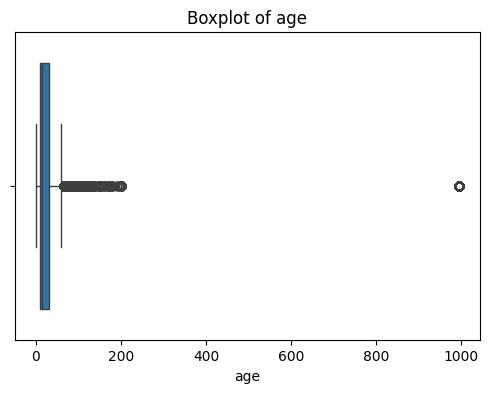

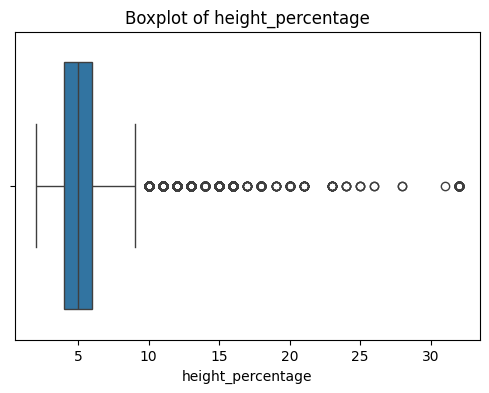

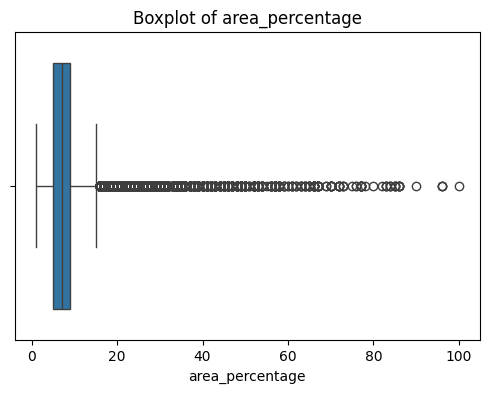

In [18]:
#EDA TECHNIQUES


import matplotlib.pyplot as plt
import seaborn as sns

features = ['age', 'height_percentage', 'area_percentage']

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [19]:
import pandas as pd
import numpy as np
from scipy.stats import skew

features = ['age', 'height_percentage', 'area_percentage']

for col in features:
    print(f"{col}")
    print("Skewness:", skew(df[col]))
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print("-"*40)

    # found that skewness is extremely high in column age - so we use iqr capping for it
    #at first try we're gonna use lgm model (tree base)  it may handle the skewness and


age
Skewness: 12.192424039649492
Min: 0
Max: 995
----------------------------------------
height_percentage
Skewness: 1.808251348936324
Min: 2
Max: 32
----------------------------------------
area_percentage
Skewness: 3.5260620183257907
Min: 1
Max: 100
----------------------------------------


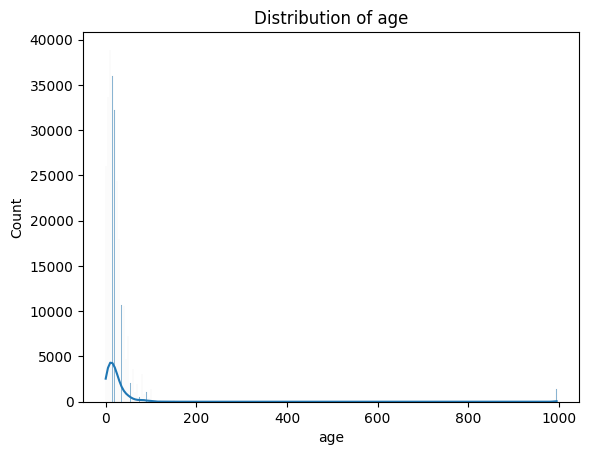

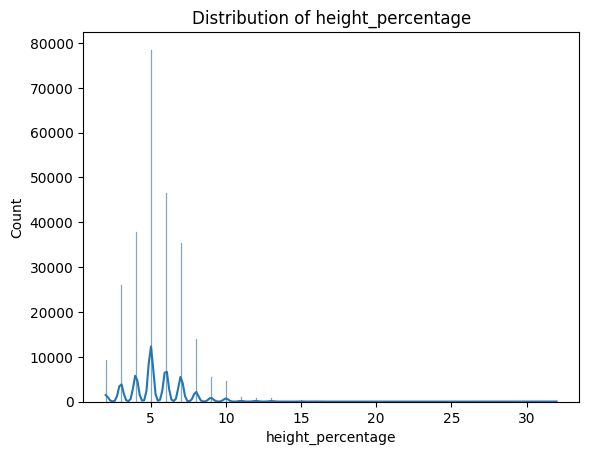

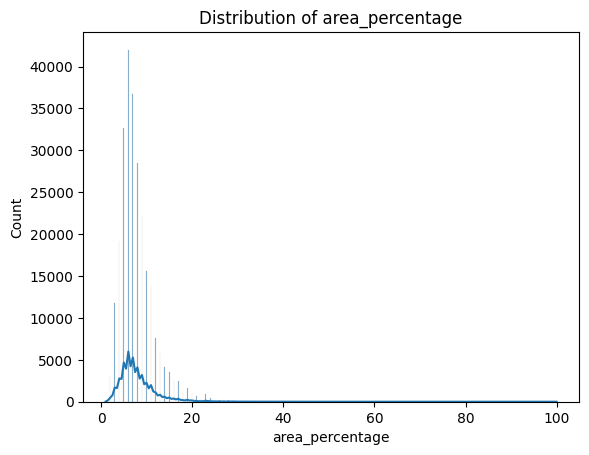

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['age', 'height_percentage', 'area_percentage']

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
!pip install optuna

In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import train_test_split

# Step 1: Use only 50% of data for tuning

X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    test_size=0.5,
    stratify=y_train,
    random_state=42
)

# Step 2: Faster objective function
def objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': 3,
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 2.0),
        'class_weight': {1: 2, 2: 1, 3: 1},
        'random_state': 42,
        'verbose': -1
    }

    model = lgb.LGBMClassifier(**params)

    cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)  # 2-fold
    scores = cross_val_score(
        model, X_tune, y_tune,   # smaller data
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )
    return scores.mean()

# Step 3: Only 20 trials
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("\n✅ Best Macro F1 (CV):", study.best_value)
print("✅ Best Params:", study.best_params)

In [21]:
!pip install imbalanced-learn
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, f1_score, cohen_kappa_score




# converting object cols to category type  cols

obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    df[col] = df[col].astype('category')

# Feature Engineering
df['age_x_height'] = df['age'] * df['height_percentage']
df['volume_proxy'] = df['area_percentage'] * df['height_percentage']

superstructure_cols = [c for c in df.columns if 'has_superstructure' in c]
df['superstructure_count'] = df[superstructure_cols].sum(axis=1)

secondary_cols = [c for c in df.columns if 'has_secondary_use' in c]
df['secondary_use_count'] = df[secondary_cols].sum(axis=1)

df['age_per_floor'] = df['age'] / (df['count_floors_pre_eq'] + 1)

# Assigning cols for X and y
X = df.drop('damage_grade', axis=1)
y = df['damage_grade']

print("Total features:", X.shape[1])

# ---- Train/test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---- Geo Risk Encoding  done after train test split to prevent data leakage ----
train_df = X_train.copy()
train_df['damage_grade'] = y_train.values

geo_risk1 = train_df.groupby('geo_level_1_id')['damage_grade'].mean()
geo_risk2 = train_df.groupby('geo_level_2_id')['damage_grade'].mean()
geo_risk3 = train_df.groupby('geo_level_3_id')['damage_grade'].mean()

X_train['geo1_risk'] = X_train['geo_level_1_id'].map(geo_risk1)
X_train['geo2_risk'] = X_train['geo_level_2_id'].map(geo_risk2)
X_train['geo3_risk'] = X_train['geo_level_3_id'].map(geo_risk3)

X_test['geo1_risk'] = X_test['geo_level_1_id'].map(geo_risk1)
X_test['geo2_risk'] = X_test['geo_level_2_id'].map(geo_risk2)
X_test['geo3_risk'] = X_test['geo_level_3_id'].map(geo_risk3)

# fill unseen geo ids in test with train mean
X_test[['geo1_risk','geo2_risk','geo3_risk']] = X_test[['geo1_risk','geo2_risk','geo3_risk']].fillna(y_train.mean())

# iqr- outlier handling
Q1 = X_train['age'].quantile(0.25)
Q3 = X_train['age'].quantile(0.75)
IQR = Q3 - Q1
upper_final = Q3 + 1.5 * IQR
lower_final = max(0, Q1 - 1.5 * IQR)

X_train['age'] = X_train['age'].clip(lower=lower_final, upper=upper_final)
X_test['age']  = X_test['age'].clip(lower=lower_final, upper=upper_final)


# Encoding cat cols for smote

cat_cols = X_train.select_dtypes(include='category').columns.tolist()
oe = OrdinalEncoder()

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded[cat_cols] = oe.fit_transform(X_train[cat_cols])
X_test_encoded[cat_cols] = oe.transform(X_test[cat_cols])

#SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_encoded, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())



# model part

# 1) parameters from optuna
best_params = {
    'n_estimators': 800,
    'learning_rate': 0.07347047162525985,
    'num_leaves': 110,
    'max_depth': 14,
    'min_child_samples': 35,
    'subsample': 0.7584786396680907,
    'colsample_bytree': 0.6577647277170828,
    'reg_alpha': 1.699099062132805,
    'reg_lambda': 1.418234660880118,
    'objective': 'multiclass',
    'num_class': 3,
    'random_state': 42,
    'verbose': -1
}
# fitting model with x train and y train
best_model = lgb.LGBMClassifier(**best_params)
best_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test_encoded, y_test)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)

#prediction part with x test encoded
y_pred = best_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))

Total features: 43
Before SMOTE: damage_grade
2    118607
3     69774
1     20099
Name: count, dtype: int64
After SMOTE: damage_grade
3    118607
2    118607
1    118607
Name: count, dtype: int64
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 0.597838
[200]	valid_0's multi_logloss: 0.592779
[300]	valid_0's multi_logloss: 0.590552
[400]	valid_0's multi_logloss: 0.58955
Early stopping, best iteration is:
[399]	valid_0's multi_logloss: 0.589495
              precision    recall  f1-score   support

           1       0.64      0.60      0.62      5025
           2       0.76      0.82      0.79     29652
           3       0.74      0.66      0.70     17444

    accuracy                           0.74     52121
   macro avg       0.71      0.69      0.70     52121
weighted avg       0.74      0.74      0.74     52121

Macro F1: 0.7026294591947094
Weighted F1: 0.7419431323923477
Cohen's Kappa: 0.5294508710352972


In [22]:
import numpy as np
from sklearn.metrics import f1_score

# Get probabilities
probs = best_model.predict_proba(X_test_encoded)

# Current thresholds are equal (0.33 each)
# We'll tune threshold for class 1 (index 0)

best_t = 0.33
best_f1 = 0

for t in np.arange(0.1, 0.5, 0.01):
    temp_probs = probs.copy()
    temp_probs[:, 0] *= (0.33 / t)  # boost class 1 sensitivity
    y_temp = np.argmax(temp_probs, axis=1) + 1
    score = f1_score(y_test, y_temp, average='macro')
    if score > best_f1:
        best_f1 = score
        best_t = t

print(f"Best threshold for class 1: {best_t:.2f}")
print(f"Best Macro F1 with tuning: {best_f1:.4f}")

# Final prediction with best threshold
final_probs = probs.copy()
final_probs[:, 0] *= (0.33 / best_t)
y_pred_tuned = np.argmax(final_probs, axis=1) + 1

print(classification_report(y_test, y_pred_tuned))
print("Macro F1:", f1_score(y_test, y_pred_tuned, average='macro'))

Best threshold for class 1: 0.23
Best Macro F1 with tuning: 0.7056
              precision    recall  f1-score   support

           1       0.60      0.68      0.63      5025
           2       0.77      0.80      0.78     29652
           3       0.74      0.66      0.70     17444

    accuracy                           0.74     52121
   macro avg       0.70      0.71      0.71     52121
weighted avg       0.74      0.74      0.74     52121

Macro F1: 0.7056154636423808
